# Restaurant EDA
- original_data/
  - Dataset_User_Agreement.pdf
  - Yelp Dataset Documentation & ToS copy.pdf
  - yelp_academic_dataset_business.json
  - yelp_academic_dataset_checkin.json
  - yelp_academic_dataset_review.json
  - yelp_academic_dataset_tip.json
  - yelp_academic_dataset_user.json
- custom_data/
  - yelp_categories.json = *categories for businesses scraped from the internet, more info in categories_scraping.ipynb*

podla priemerneho poctu recenzii v mestach (alebo poctu hviezdiciek)
pomocou LLM vytiahnut z recenzii booleany o zakaznikoch (preferuje_nizke_ceny, ma_rad_taliansku_kuchynu)
checkiny mozeme ignorovat
ak si zvolime businessy, co maju malo recenzii (vacsina ma od 5 do 15), tak nemozeme robit time-weighted recommendation ako v ElasticSearch
datumy recenzii mozeme vyhodit ak nebudeme robit time weight-based boost (asi nebudeme; malo recenzii)



CHECKIN preč!

mozeme analyzovat aj tipy (zatiaľ; ak z nich nič nebude, tak ich vyhodíme)

opening / closing (mozno cez rozdiel closing - opening este zistime)
este poriesit atributy, je tam vela chybajucich hodnot (1 = true, 0 = false, 0.5 = nan??)
geoudaje okrem mesta a štátu definitivne vyhodit
postal code a meno businessu tiez nemusime riesit

is_open = 0 vyhodit
elite z userov vyhodit
useful, funny a cool z userov vyhodit, vacsina ma aj tak 0
average_stars moze ist prec
complimenty prec, z businesses tiez vyhodit useful, funny, cool
number_of_friends moze ist prec (friends ako taki asi tiez)
este by som mozno do dokumentacie NEZABUDOL napisat, ze sme neriesili photos.json

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from pprint import pp as pprint
import re
import json
from icecream import ic
from itertools import product
from matplotlib import pyplot as plt
from dateutil import parser
import datetime
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [2]:
with open("custom_data/yelp_categories.json") as f:
    file_content = f.read()
    categories_dict = json.loads(file_content)

categories = list()
def recur_get_categories(categories_dict: dict):
    for key, val in categories_dict.items():
        categories.append(key)
        for el in val:
            if type(el) == str:
                categories.append(el)
            if type(el) == dict:
                recur_get_categories(el)
recur_get_categories(categories_dict)

In [3]:
DATASET_PATH = Path("original_data/yelp_json")
CUSTOM_DATASET_PATH = Path("custom_data/")

In [4]:
YELP_RED = "#e00707"

## Business - filtering

In [5]:
business = pd.read_json(DATASET_PATH / "yelp_academic_dataset_business.json", lines=True)
business

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [6]:
categories_with_comma = list(filter(lambda category: "," in category, categories))
pprint(categories_with_comma)

['Beer, Wine & Spirits',
 'Wills, Trusts, & Probates',
 'Books, Mags, Music & Video',
 'Used, Vintage & Consignment']


In [7]:
new_business_categories_list = list()
for business_categories in business["categories"]:
    # if a category name contains a comma, replace it with a semicolon
    if type(business_categories) == str:
        for category_with_comma in categories_with_comma:
            business_categories = business_categories.replace(category_with_comma, category_with_comma.replace(",", ";"))
    new_business_categories_list.append(business_categories)

new_business_categories_to_add = list()
for new_business_categories in new_business_categories_list:
    if type(new_business_categories) == str:
        new_business_categories = new_business_categories.split(",")
    elif type(new_business_categories) == float:
        new_business_categories = list()
    # getting rid of trailing whitespaces
    new_business_categories_to_add.append([new_business_category.strip() for new_business_category in new_business_categories])

business["new_categories"] = new_business_categories_to_add

In [8]:
unique_categories = set()
for business_row in business["new_categories"]:
    for category in business_row:
        unique_categories.add(category)

In [9]:
# one hot indexing all the categories
new_category_labels_dict = dict()
for unique_category in unique_categories:
    unique_category_one_hot = [int(unique_category in categories) for categories in business["new_categories"]]

    new_category_labels_dict[f"{unique_category}_category"] = unique_category_one_hot
business = business.assign(**new_category_labels_dict)
business = business.copy()

/tmp/ipykernel_87533/21377948.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  business = business.assign(**new_category_labels_dict)


In [10]:
filtered_business = business[business["Restaurants_category"] == 1]

In [11]:
display(filtered_business.head())
print("df shape:", filtered_business.shape)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Employment Law_category,Embroidery & Crochet_category,Eyebrow Services_category,Sheds & Outdoor Storage_category,Breweries_category,Arcades_category,Zoos_category,Body Contouring_category,Demolition Services_category,Head Shops_category
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0,0,0,0,0,0,0,0,0,0
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,0,0,0,0,0,0,0,0,0,0
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,0,0,0,0,0,0,0,0,0,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,0,0,0,0,0,0,0,0,0,0
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,0,0,0,0,0,0,0,0,0,0


df shape: (52268, 1320)


In [12]:
filtered_business = filtered_business[filtered_business["is_open"] == 1]

In [13]:
filtered_business = filtered_business.drop(columns=["Restaurants_category", "is_open"])

In [14]:
display(filtered_business)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Employment Law_category,Embroidery & Crochet_category,Eyebrow Services_category,Sheds & Outdoor Storage_category,Breweries_category,Arcades_category,Zoos_category,Body Contouring_category,Demolition Services_category,Head Shops_category
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0,0,0,0,0,0,0,0,0,0
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,0,0,0,0,0,0,0,0,0,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,0,0,0,0,0,0,0,0,0,0
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,0,0,0,0,0,0,0,0,0,0
12,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150323,w_4xUt-1AyY2ZwKtnjW0Xg,Bittercreek Alehouse,246 N 8th St,Boise,ID,83702,43.616590,-116.202383,4.5,998,...,0,0,0,0,0,0,0,0,0,0
150325,l9eLGG9ZKpLJzboZq-9LRQ,Wawa,19 N Bishop Ave,Clifton Heights,PA,19018,39.925656,-75.310344,3.0,11,...,0,0,0,0,0,0,0,0,0,0
150327,cM6V90ExQD6KMSU3rRB5ZA,Dutch Bros Coffee,1181 N Milwaukee St,Boise,ID,83704,43.615401,-116.284689,4.0,33,...,0,0,0,0,0,0,0,0,0,0
150336,WnT9NIzQgLlILjPT0kEcsQ,Adelita Taqueria & Restaurant,1108 S 9th St,Philadelphia,PA,19147,39.935982,-75.158665,4.5,35,...,0,0,0,0,0,0,0,0,0,0


In [15]:
category_columns_to_remove = [column for column in filtered_business.filter(like="_category").columns if filtered_business[column].sum() == 0]
pprint(category_columns_to_remove)
print(len(category_columns_to_remove))

['Art Restoration_category',
 'Gastroenterologist_category',
 'Acupuncture_category',
 'Valet Services_category',
 'Kiosk_category',
 'Memory Care_category',
 'Mobile Home Dealers_category',
 'Registration Services_category',
 'Packing Supplies_category',
 'Oxygen Bars_category',
 'House Sitters_category',
 'Hot Tub & Pool_category',
 'Archery_category',
 'Reptile Shops_category',
 'Emergency Rooms_category',
 'Furniture Repair_category',
 'Computers_category',
 'Vacation Rental Agents_category',
 'Hockey Equipment_category',
 'Bounce House Rentals_category',
 'Fire Protection Services_category',
 'Gerontologists_category',
 'Event Photography_category',
 'Leather Goods_category',
 'Whale Watching Tours_category',
 'Diamond Buyers_category',
 'Hepatologists_category',
 'Trade Fairs_category',
 'Shoe Shine_category',
 'Musical Instrument Services_category',
 'Cosmetic Dentists_category',
 'Blow Dry/Out Services_category',
 'Races & Competitions_category',
 'Fireworks_category',
 'Clowns

In [16]:
filtered_business = filtered_business.drop(columns=category_columns_to_remove)

In [17]:
filtered_business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Banks & Credit Unions_category,Officiants_category,Chiropractors_category,Service Stations_category,Sports Bars_category,Employment Law_category,Eyebrow Services_category,Breweries_category,Arcades_category,Head Shops_category
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0,0,0,0,0,0,0,0,0,0
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,0,0,0,0,0,0,0,0,0,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,0,0,0,0,0,0,0,0,0,0
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,0,0,0,0,0,0,0,0,0,0
12,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,...,0,0,0,0,0,0,0,0,0,0


As we can see above, there are still some non restaurant categories that are not relevant for us (such as Radiologists, Music & DVDs).

In [18]:
restaurant_categories_dict = categories_dict["Restaurants"]

In [19]:
restaurant_categories = list()
def recur_get_categories(categories_dict: dict, categories_list: list):
    if type(categories_dict) == list:
        for el in categories_dict:
            if type(el) == str:
                categories_list.append(el)
            if type(el) == dict:
                recur_get_categories(el, categories_list=restaurant_categories)
    elif type(categories_dict) == dict:
        for key, val in categories_dict.items():
            categories_list.append(key)
            for el in val:
                if type(el) == str:
                    categories_list.append(el)
                if type(el) == dict:
                    recur_get_categories(el, categories_list=restaurant_categories)
    else:
        print(type(categories_dict))
recur_get_categories(restaurant_categories_dict, categories_list=restaurant_categories)

In [20]:
restaurant_categories
len(restaurant_categories)

312

In [21]:
all_categories = {column for column in filtered_business.filter(like="_category").columns}
print(len(all_categories))

689


In [22]:
non_restaurant_categories_to_remove = all_categories - set([restaurant_category + "_category" for restaurant_category in restaurant_categories])
pprint(non_restaurant_categories_to_remove)

{'Acai Bowls_category',
 'Accessories_category',
 'Accountants_category',
 'Active Life_category',
 'Adult Education_category',
 'Adult Entertainment_category',
 'Adult_category',
 'Advertising_category',
 'Air Duct Cleaning_category',
 'Airlines_category',
 'Airport Lounges_category',
 'Airport Shuttles_category',
 'Airport Terminals_category',
 'Airports_category',
 'Amateur Sports Teams_category',
 'Amusement Parks_category',
 'Animal Shelters_category',
 'Antiques_category',
 'Apartments_category',
 'Appliances & Repair_category',
 'Appliances_category',
 'Aquariums_category',
 'Arabic_category',
 'Arcades_category',
 'Art Classes_category',
 'Art Galleries_category',
 'Art Museums_category',
 'Art Tours_category',
 'Arts & Crafts_category',
 'Arts & Entertainment_category',
 'Auction Houses_category',
 'Audio/Visual Equipment Rental_category',
 'Auto Customization_category',
 'Auto Detailing_category',
 'Auto Glass Services_category',
 'Auto Loan Providers_category',
 'Auto Parts 

In [23]:
print(len(non_restaurant_categories_to_remove))

528


In [24]:
filtered_business = filtered_business.drop(columns=non_restaurant_categories_to_remove)

In [25]:
filtered_business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Taiwanese_category,Pita_category,Spanish_category,Canadian (New)_category,Georgian_category,African_category,Austrian_category,American (New)_category,Barbeque_category,Delis_category
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0,0,0,0,0,0,0,0,0,0
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,0,0,0,0,0,0,0,0,0,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,0,0,0,0,0,0,0,0,0,0
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,0,0,0,0,0,0,0,0,0,0
12,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,...,0,0,0,0,0,0,0,0,0,0


In [26]:
filtered_business = filtered_business.drop(columns=["name", "address", "postal_code", "latitude", "longitude", "categories", "new_categories"])

In [27]:
# uprava hours
weekdays = ("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday")
actions = ("opening", "closing")
time_units = ("hour", "minute")

# create a dictionary to add to the business dataframe
business_hours_to_add = {f"{weekday.lower()}_{action}_{time_unit}": [] for weekday, action, time_unit in product(weekdays, actions, time_units)}

timestamp_regex = re.compile(r"(\d{1,2}):(\d{1,2})-(\d{1,2}):(\d{1,2})")

for business_hours_dict in filtered_business["hours"]:
    for key in business_hours_to_add.keys():
        business_hours_to_add[key].append(None)
    if type(business_hours_dict) == dict:
        for key, val in business_hours_dict.items():
            timestamp_match = re.search(timestamp_regex, val)
            opening_hour = timestamp_match.group(1)
            opening_minute = timestamp_match.group(2)
            closing_hour = timestamp_match.group(3)
            closing_minute = timestamp_match.group(4)
            business_hours_to_add[f"{key.lower()}_opening_hour"][-1] = int(opening_hour)
            business_hours_to_add[f"{key.lower()}_opening_minute"][-1] = int(opening_minute)
            business_hours_to_add[f"{key.lower()}_closing_hour"][-1] = int(closing_hour)
            business_hours_to_add[f"{key.lower()}_closing_minute"][-1] = int(closing_minute)

filtered_business = filtered_business.assign(**business_hours_to_add)

# change datatype for the added columns
for time_column in business_hours_to_add.keys():
    filtered_business = filtered_business.astype({time_column: "Int32"})

In [28]:
filtered_business.head()

,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,thursday_closing_hour,thursday_closing_minute,friday_opening_hour,friday_opening_minute,friday_closing_hour,friday_closing_minute,saturday_opening_hour,saturday_opening_minute,saturday_closing_hour,saturday_closing_minute
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,20,0,7,0,21,0,7,0,21,0
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,22,0,9,0,0,0,9,0,22,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,16,0,6,0,16,0,6,0,17,0
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,14,0,11,0,14,0,5,0,10,0
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,22,0,6,0,22,0,6,0,22,0


In [29]:
for weekday, action in product(weekdays, actions):
    filtered_business[f"{weekday.lower()}_{action}_time"] = filtered_business[f"{weekday.lower()}_{action}_hour"] * 60 + filtered_business[f"{weekday.lower()}_{action}_minute"]

/tmp/ipykernel_87533/2372019139.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filtered_business[f"{weekday.lower()}_{action}_time"] = filtered_business[f"{weekday.lower()}_{action}_hour"] * 60 + filtered_business[f"{weekday.lower()}_{action}_minute"]


In [30]:
filtered_business = filtered_business.copy()

In [31]:
filtered_business.head()

,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,tuesday_opening_time,tuesday_closing_time,wednesday_opening_time,wednesday_closing_time,thursday_opening_time,thursday_closing_time,friday_opening_time,friday_closing_time,saturday_opening_time,saturday_closing_time
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,420,1200,420,1200,420,1200,420,1260,420,1260
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,360,1320,360,1320,360,1320,540,0,540,1320
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,360,1260,360,1260,360,960,360,960,360,1020
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,660,840,660,840,660,840,660,840,300,600
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,360,1320,360,1320,360,1320,360,1320,360,1320


In [32]:
time_columns_to_remove = {column for column in filtered_business.filter(like="_hour").columns}| {column for column in filtered_business.filter(like="_minute").columns}

In [33]:
print(time_columns_to_remove)
print(len(time_columns_to_remove))

{'friday_closing_hour', 'wednesday_closing_hour', 'friday_opening_minute', 'sunday_closing_hour', 'tuesday_closing_minute', 'saturday_closing_hour', 'wednesday_closing_minute', 'monday_opening_minute', 'monday_closing_minute', 'saturday_closing_minute', 'monday_closing_hour', 'wednesday_opening_minute', 'sunday_closing_minute', 'tuesday_opening_minute', 'thursday_opening_hour', 'tuesday_closing_hour', 'thursday_opening_minute', 'wednesday_opening_hour', 'saturday_opening_hour', 'friday_opening_hour', 'monday_opening_hour', 'tuesday_opening_hour', 'thursday_closing_minute', 'saturday_opening_minute', 'sunday_opening_minute', 'friday_closing_minute', 'sunday_opening_hour', 'thursday_closing_hour'}
28


In [34]:
filtered_business = filtered_business.drop(columns=time_columns_to_remove)

In [35]:
filtered_business.head()

,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,tuesday_opening_time,tuesday_closing_time,wednesday_opening_time,wednesday_closing_time,thursday_opening_time,thursday_closing_time,friday_opening_time,friday_closing_time,saturday_opening_time,saturday_closing_time
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,420,1200,420,1200,420,1200,420,1260,420,1260
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,360,1320,360,1320,360,1320,540,0,540,1320
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,360,1260,360,1260,360,960,360,960,360,1020
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,660,840,660,840,660,840,660,840,300,600
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,360,1320,360,1320,360,1320,360,1320,360,1320


In [36]:
for weekday, time_unit in product(weekdays, time_units):
    filtered_business[f"{weekday.lower()}_opening_length_hours"] = abs(filtered_business[f"{weekday.lower()}_closing_time"] - filtered_business[f"{weekday.lower()}_opening_time"]) / 60

In [37]:
filtered_business.head()

,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,friday_closing_time,saturday_opening_time,saturday_closing_time,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,1260,420,1260,14.0,13.0,13.0,13.0,13.0,14.0,14.0
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,0,540,1320,14.0,0.0,16.0,16.0,16.0,9.0,13.0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,960,360,1020,15.0,0.0,15.0,15.0,10.0,10.0,11.0
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,840,300,600,3.0,3.0,3.0,3.0,3.0,3.0,5.0
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,1320,360,1320,16.0,16.0,16.0,16.0,16.0,16.0,16.0


In [38]:
time_columns_to_remove = [column for column in filtered_business.filter(like="_time").columns]
print(time_columns_to_remove)
print(len(time_columns_to_remove))
filtered_business = filtered_business.drop(columns=time_columns_to_remove)
filtered_business.head()

['sunday_opening_time', 'sunday_closing_time', 'monday_opening_time', 'monday_closing_time', 'tuesday_opening_time', 'tuesday_closing_time', 'wednesday_opening_time', 'wednesday_closing_time', 'thursday_opening_time', 'thursday_closing_time', 'friday_opening_time', 'friday_closing_time', 'saturday_opening_time', 'saturday_closing_time']
14


,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,American (New)_category,Barbeque_category,Delis_category,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,0,0,0,14.0,13.0,13.0,13.0,13.0,14.0,14.0
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,0,0,0,14.0,0.0,16.0,16.0,16.0,9.0,13.0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,0,0,0,15.0,0.0,15.0,15.0,10.0,10.0,11.0
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,0,0,0,3.0,3.0,3.0,3.0,3.0,3.0,5.0
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,0,0,0,16.0,16.0,16.0,16.0,16.0,16.0,16.0


In [39]:
filtered_business

,business_id,city,state,stars,review_count,attributes,hours,Eastern European_category,Mediterranean_category,Live/Raw Food_category,...,American (New)_category,Barbeque_category,Delis_category,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",0,0,0,...,0,0,0,14.0,13.0,13.0,13.0,13.0,14.0,14.0
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '...",0,0,0,...,0,0,0,14.0,0.0,16.0,16.0,16.0,9.0,13.0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '...",0,0,0,...,0,0,0,15.0,0.0,15.0,15.0,10.0,10.0,11.0
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'...",0,0,0,...,0,0,0,3.0,3.0,3.0,3.0,3.0,3.0,5.0
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ...",0,0,0,...,0,0,0,16.0,16.0,16.0,16.0,16.0,16.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150323,w_4xUt-1AyY2ZwKtnjW0Xg,Boise,ID,4.5,998,"{'BikeParking': 'True', 'Alcohol': 'u'full_bar...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-22:0', ...",0,0,0,...,0,0,0,11.0,0.0,11.0,11.0,12.0,12.5,12.0
150325,l9eLGG9ZKpLJzboZq-9LRQ,Clifton Heights,PA,3.0,11,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150327,cM6V90ExQD6KMSU3rRB5ZA,Boise,ID,4.0,33,"{'WiFi': ''free'', 'RestaurantsGoodForGroups':...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-17:0', '...",0,0,0,...,0,0,0,0.0,0.0,17.0,0.0,0.0,0.0,0.0
150336,WnT9NIzQgLlILjPT0kEcsQ,Philadelphia,PA,4.5,35,"{'WheelchairAccessible': 'False', 'Restaurants...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",0,0,0,...,0,0,0,11.0,11.0,11.0,<NA>,11.0,9.0,9.0


In [40]:
filtered_business = filtered_business.drop(columns=["hours", "attributes"]) # este sa rozhodnut, co urobit s ATTRIBUTES
display(filtered_business)

,business_id,city,state,stars,review_count,Eastern European_category,Mediterranean_category,Live/Raw Food_category,Southern_category,Supper Clubs_category,...,American (New)_category,Barbeque_category,Delis_category,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
3,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,4.0,80,0,0,0,0,0,...,0,0,0,14.0,13.0,13.0,13.0,13.0,14.0,14.0
5,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,2.0,6,0,0,0,0,0,...,0,0,0,14.0,0.0,16.0,16.0,16.0,9.0,13.0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,1.5,10,0,0,0,0,0,...,0,0,0,15.0,0.0,15.0,15.0,10.0,10.0,11.0
11,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,4.0,10,0,0,0,0,0,...,0,0,0,3.0,3.0,3.0,3.0,3.0,3.0,5.0
12,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,2.5,28,0,0,0,0,0,...,0,0,0,16.0,16.0,16.0,16.0,16.0,16.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150323,w_4xUt-1AyY2ZwKtnjW0Xg,Boise,ID,4.5,998,0,0,0,0,0,...,0,0,0,11.0,0.0,11.0,11.0,12.0,12.5,12.0
150325,l9eLGG9ZKpLJzboZq-9LRQ,Clifton Heights,PA,3.0,11,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150327,cM6V90ExQD6KMSU3rRB5ZA,Boise,ID,4.0,33,0,0,0,0,0,...,0,0,0,0.0,0.0,17.0,0.0,0.0,0.0,0.0
150336,WnT9NIzQgLlILjPT0kEcsQ,Philadelphia,PA,4.5,35,0,0,0,0,0,...,0,0,0,11.0,11.0,11.0,<NA>,11.0,9.0,9.0


In [41]:
business = filtered_business.reset_index(drop=True)

In [42]:
restaurant_ids = business["business_id"].tolist()

In [43]:
pprint(restaurant_ids)

['MTSW4McQd7CbVtyjqoe9mw',
 'CF33F8-E6oudUQ46HnavjQ',
 'bBDDEgkFA1Otx9Lfe7BZUQ',
 'eEOYSgkmpB90uNA7lDOMRA',
 'il_Ro8jwPlHresjw9EGmBg',
 'MUTTqe8uqyMdBl186RmNeA',
 'ROeacJQwBeh05Rqg7F6TCg',
 'kfNv-JZpuN6TVNSO6hHdkw',
 '9OG5YkX1g2GReZM0AskizA',
 'sqSqqLy0sN8n2IZrAbzidQ',
 'kV_Q1oqis8Qli8dUoGpTyQ',
 'aPNXGTDkf-4bjhyMBQxqpQ',
 'ljxNT9p0y7YMPx0fcNBGig',
 'ABxoFuzZy5mqQ8C5FJJajQ',
 'seKihQKpGGnCeLuELRQPSQ',
 '8rb-3VYXE37IZix4yOdskw',
 'aCDY7vXYMs54EbYuQScsnQ',
 'pJfh3Ct8iL58NZa8ta-a5w',
 'ppFCk9aQkM338Rgwpl2F5A',
 'IDtLPgUrqorrpqSLdfMhZQ',
 'YNjyv0gfOr2g8lbmUpTnKg',
 'LhpPSrulqVeTyJeK2xydvQ',
 'oaboaRBUgGjbo2kfUIKDLQ',
 'RK6-cJ9hj53RzOlCBmpT-g',
 'knQ4vIgx-r85kjlWVVjcpQ',
 'EuRGgOwJ0g1vTj2R04j37Q',
 'TLZ3-eDPLhUzfsWO4ad6Ug',
 'Dy91wdWkwtI_qgjAIZ0Niw',
 'vje0KIiE7vtpx7JzmBx5LQ',
 'VrGxoSNZfSiT-G4OqRRGIw',
 'VZzivJEbmHItOxNXJB3SpA',
 'anLQj9AM8vjbcLSIE0iUgg',
 'Cdytv_YhJO0W0Ab8t2xLtg',
 '3BJxm-HnvzdwD1zjmSbmyQ',
 '9C2rpb56aQvW0ViZHK9sPw',
 'SZU9c8V2GuREDN5KgyHFJw',
 'aNtKyc2rr-uK5cqzY9TVQQ',
 

In [44]:
## Filtering reviews

In [45]:
# since most reviews are not useful, cool, nor funny, we drop these columns
# reviews.drop(columns=["useful", "cool", "funny"])

## Business

In [46]:
business.info()

<class 'pandas.DataFrame'>
RangeIndex: 34987 entries, 0 to 34986
Columns: 173 entries, business_id to saturday_opening_length_hours
dtypes: Float64(7), float64(1), int64(162), str(3)
memory usage: 46.4 MB


In [47]:
business.describe()

,stars,review_count,Eastern European_category,Mediterranean_category,Live/Raw Food_category,Southern_category,Supper Clubs_category,Irish_category,Indian_category,Syrian_category,...,American (New)_category,Barbeque_category,Delis_category,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
count,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,34987.000000,...,34987.000000,34987.000000,34987.000000,27312.0,28003.0,29440.0,30831.0,31310.0,31477.0,30799.0
mean,3.523895,104.142767,0.000029,0.020493,0.001315,0.018607,0.000086,0.003430,0.013091,0.000229,...,0.103724,0.028010,0.049561,9.147904,7.218632,9.489913,9.446469,9.378459,9.477176,9.490194
std,0.862661,220.590683,0.005346,0.141682,0.036236,0.135134,0.009260,0.058465,0.113664,0.015120,...,0.304907,0.165005,0.217040,3.529554,5.260115,3.541201,3.533845,3.54877,3.581873,3.507429
min,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,3.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,7.0,0.0,8.0,8.0,8.0,8.0,8.0
50%,3.500000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,10.0,9.0,10.0,10.0,10.0,10.0,10.0
75%,4.000000,109.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,11.0,11.0,11.25,11.0,11.0,11.5,11.5
max,5.000000,7568.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,23.983333,23.983333,23.983333,23.983333,23.983333,23.983333,23.983333


### Stars

[]

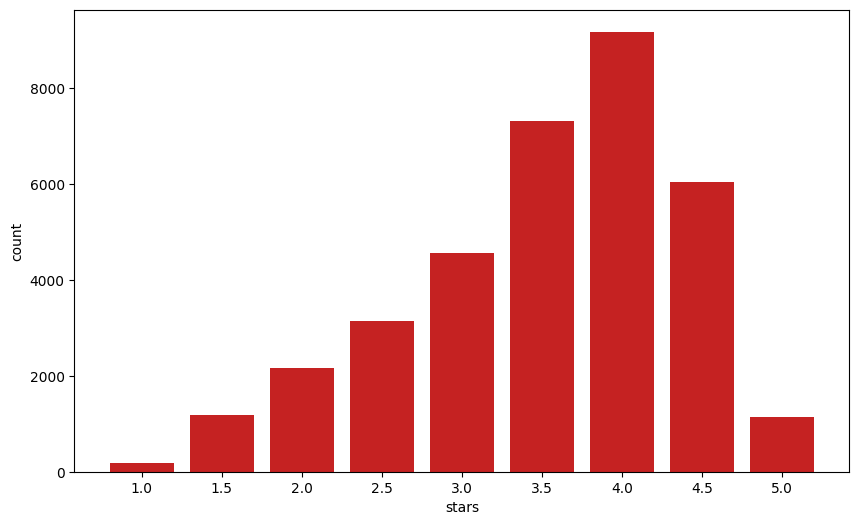

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(data=business, x="stars", color=YELP_RED)
plt.plot()

[]

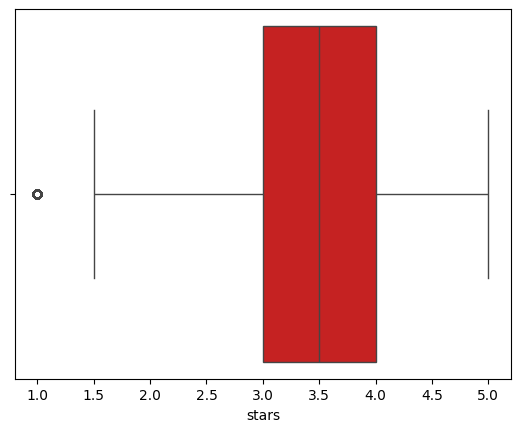

In [49]:
sns.boxplot(data=business, x="stars", color=YELP_RED)
plt.plot()

### Review Count

Text(0, 0.5, 'Number of restaurants')

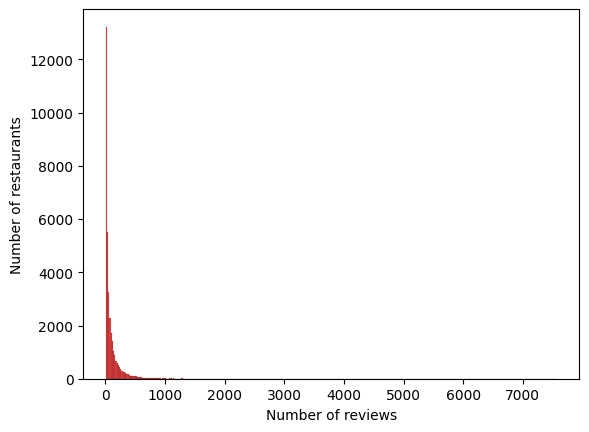

In [50]:
review_histplot = sns.histplot(data=business, x="review_count", color=YELP_RED)
review_histplot.set_xlabel("Number of reviews")
review_histplot.set_ylabel("Number of restaurants")

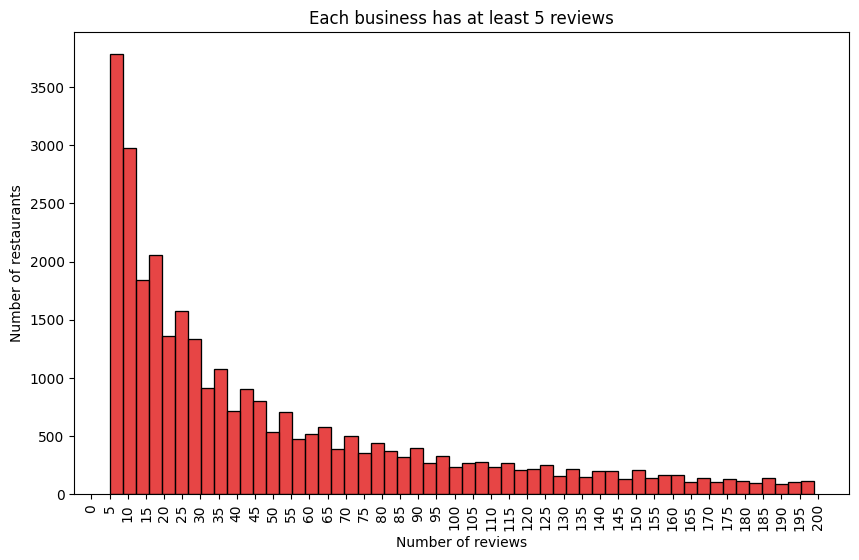

In [51]:
plt.figure(figsize=(10, 6))
review_histplot = sns.histplot(data=business[business["review_count"] < 200], x="review_count", color=YELP_RED)
review_histplot.set_xticks(range(0, 205, 5))
review_histplot.set_xlabel("Number of reviews")
review_histplot.set_ylabel("Number of restaurants")
review_histplot.set_title("Each business has at least 5 reviews")
plt.xticks(rotation=90)
plt.show()

### Business locations

In [52]:
state_counts = business.value_counts("state", dropna=False)
pd.DataFrame({"state": state_counts.index, "count": state_counts.values, "count(%)": (100 * state_counts / state_counts.sum()).values})

,state,count,count(%)
0,PA,8069,23.062852
1,FL,5920,16.920570
2,TN,3030,8.660360
3,IN,2836,8.105868
4,MO,2723,7.782891
5,NJ,2415,6.902564
6,LA,2343,6.696773
7,AZ,1803,5.153343
8,AB,1734,4.956127
9,NV,1075,3.072570


All businesses are in the US, except for approximately 1700 businesses in Alberta (AB), Canada. There is also a single business in XMS. While XMS is not a standardised abbreviation, I was able to find out that it means Merseyside, a county in Northern England.

In [53]:
business[business["state"] == "XMS"]

,business_id,city,state,stars,review_count,Eastern European_category,Mediterranean_category,Live/Raw Food_category,Southern_category,Supper Clubs_category,...,American (New)_category,Barbeque_category,Delis_category,sunday_opening_length_hours,monday_opening_length_hours,tuesday_opening_length_hours,wednesday_opening_length_hours,thursday_opening_length_hours,friday_opening_length_hours,saturday_opening_length_hours
22965,IvQs2hhXKZ4NgZhVZ5jjjQ,Liverpool,XMS,4.0,5,0,0,0,0,0,...,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


![attachment:merseyside](images/liverpool_XMS.png)

In [54]:
city_counts = business[["city", "state"]].value_counts()
city_counts = pd.DataFrame(
    {
        "city": [f"{city[0]}, {city[1]}" for city in city_counts.index],
        "count": city_counts.values,
        "count(%)": (100 * city_counts / city_counts.sum()).values
    }
)
city_counts

,city,count,count(%)
0,"Philadelphia, PA",3525,10.075171
1,"Tampa, FL",1964,5.613514
2,"Indianapolis, IN",1904,5.442021
3,"Nashville, TN",1681,4.804642
4,"Tucson, AZ",1639,4.684597
...,...,...,...
858,"Mount Holly,, NJ",1,0.002858
859,"Tampa Florida, FL",1,0.002858
860,"UPPER MORELAND, PA",1,0.002858
861,"philadelphia, PA",1,0.002858


We have most data for Philadelphia (PA), Tampa (FL), Indianapolis (IN), and so on.

### Business types (categories)

Categories are basically long strings, wherein each category is separated by a comma.

Not all possible YELP categories are present in our dataset.

In [55]:
popular_categories = business.filter(like="_category", axis=1).sum(axis=0, numeric_only=True).sort_values(ascending=False)

In [56]:
popular_categories_df = pd.DataFrame(
    {
        "category": popular_categories.index,
        "count": popular_categories.values,
        "count(%)": (100 * popular_categories / len(business)).values
    }
)
with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.precision', 3,
    ):
    display(popular_categories_df)

,category,count,count(%)
0,Sandwiches_category,6075,17.364
1,American (Traditional)_category,5531,15.809
2,Fast Food_category,5516,15.766
3,Pizza_category,5090,14.548
4,Breakfast & Brunch_category,4415,12.619
5,Burgers_category,4275,12.219
6,American (New)_category,3629,10.372
7,Mexican_category,3315,9.475
8,Italian_category,2953,8.440
9,Seafood_category,2479,7.085


### Attributes

In [57]:
# TODO: decide how to handle attributes

# all_possible_attributes = dict()
# for attribute_dict in business["attributes"].dropna():
#     for key, val in attribute_dict.items():
#         if key not in all_possible_attributes.keys():
#             all_possible_attributes[key] = set()
#         all_possible_attributes[key].add(val)
# pprint(all_possible_attributes)

### Hours

The `hours` column contains a dict with workdays and their respective openings and closings.

In [58]:
weekdays = ("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday")
# actions = ("opening", "closing")
# time_units = ("hour", "minute")

Now, visualisations of opening and closing times throughout the week.

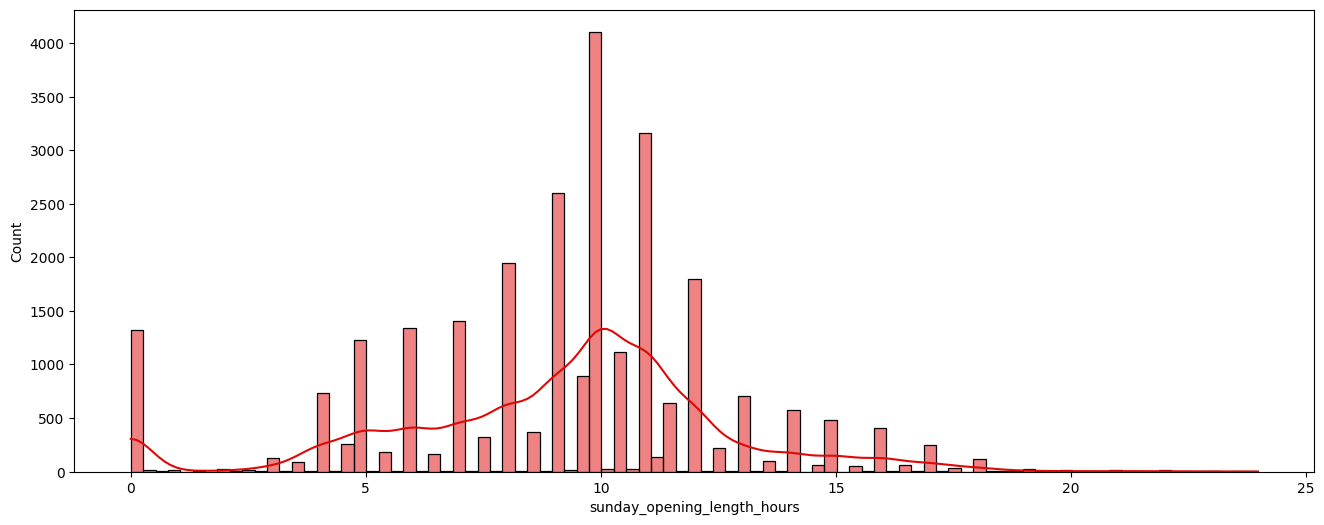

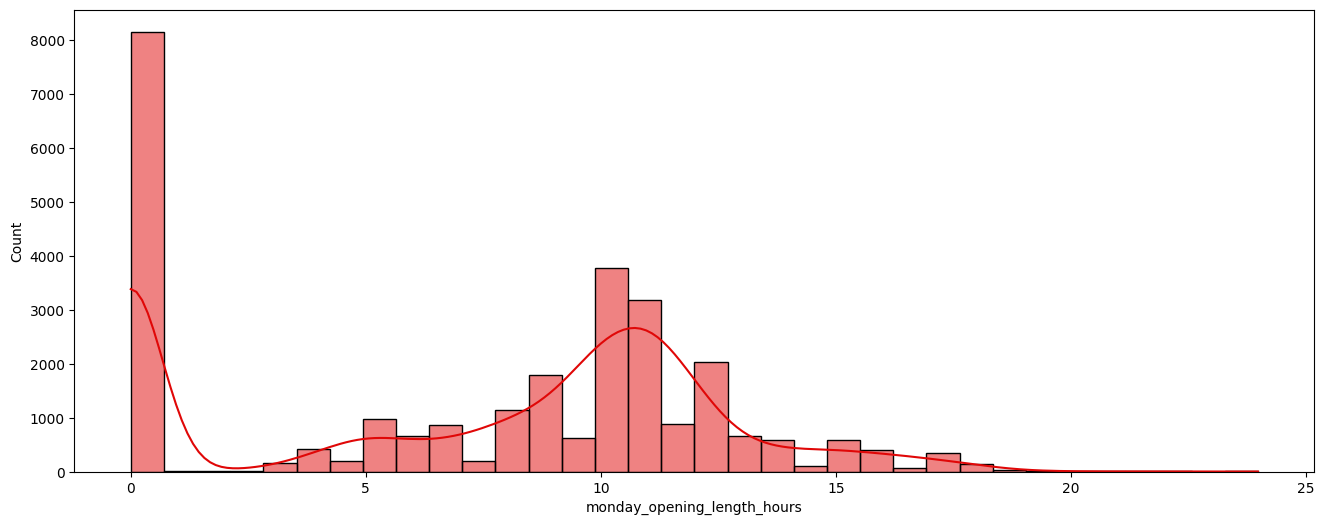

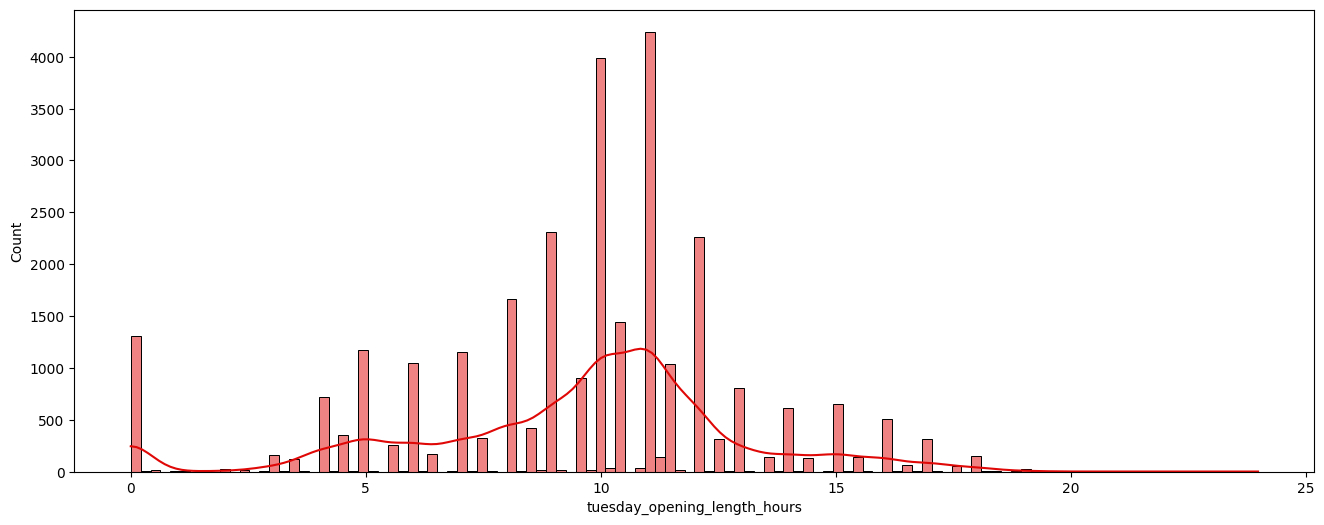

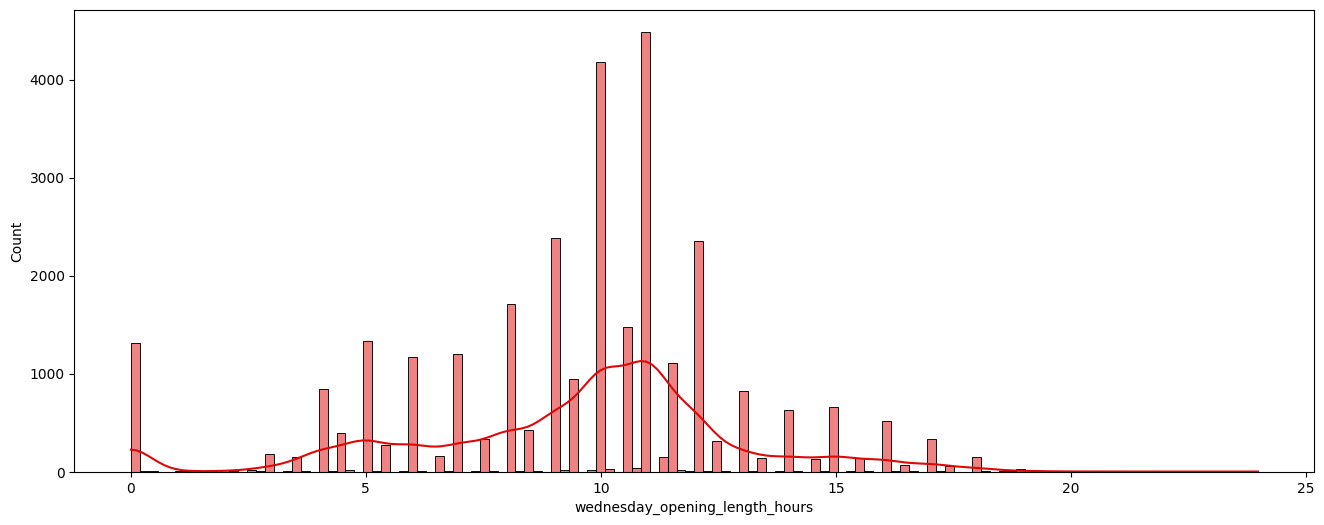

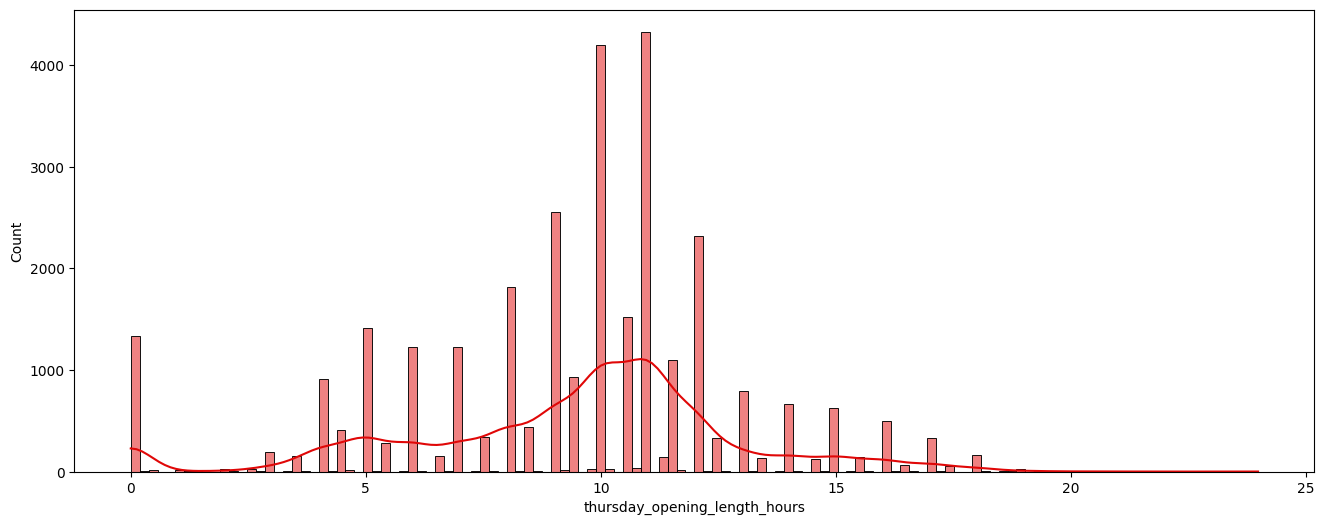

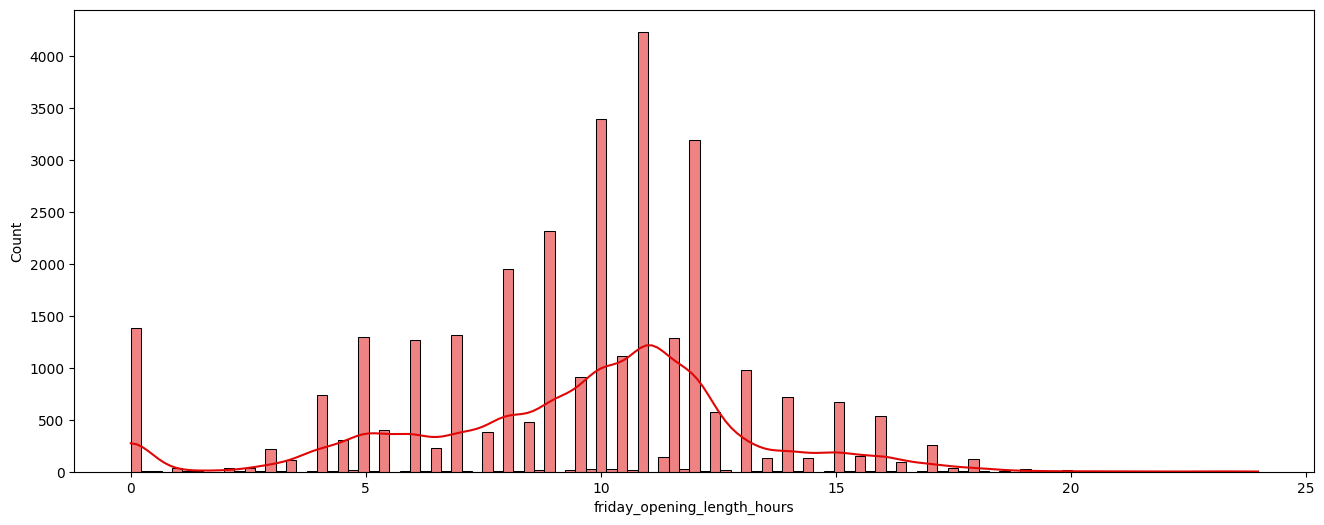

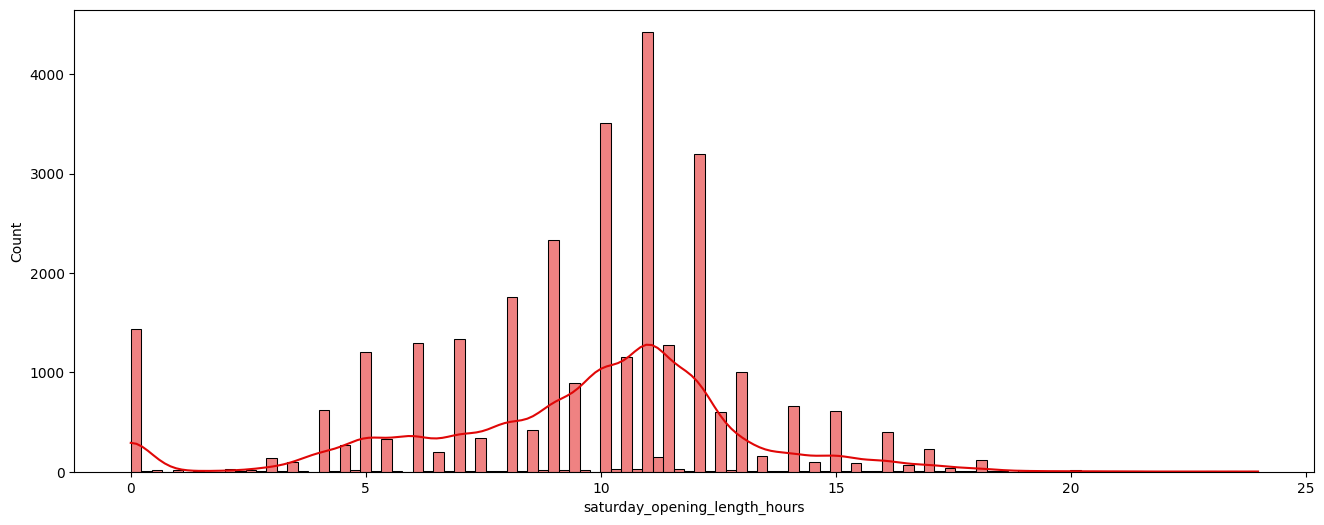

In [59]:
for weekday in weekdays:
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    to_plot = sns.histplot(data=business, x=f"{weekday.lower()}_opening_length_hours", color=YELP_RED, kde=True, ax=ax)
    plt.plot()

## Checkin

We ignore the checkin data as they do not have any use for recommendation system.

## Review

WARNING: This is a modified version of reviews without the `text` column.

In [60]:
review = pd.read_csv(CUSTOM_DATASET_PATH / "review_for_vis.csv")
review_nrow = review.shape[0]

In [61]:
filtered_review = review[review["business_id"].isin(restaurant_ids)]
filtered_review_nrow = filtered_review.shape[0]

In [62]:
filtered_review_nrow / review_nrow

0.5398596336627431

In [63]:
filtered_review.info()

<class 'pandas.DataFrame'>
Index: 3773770 entries, 0 to 6990279
Data columns (total 9 columns):
 #   Column       Dtype
---  ------       -----
 0   review_id    str  
 1   user_id      str  
 2   business_id  str  
 3   stars        int64
 4   useful       int64
 5   funny        int64
 6   cool         int64
 7   date         str  
 8   text_length  int64
dtypes: int64(5), str(4)
memory usage: 287.9 MB


In [64]:
filtered_review.describe()

,stars,useful,funny,cool,text_length
count,3.773770e+06,3.773770e+06,3.773770e+06,3.773770e+06,3.773770e+06
mean,3.831686e+00,9.551040e-01,2.910244e-01,4.805338e-01,5.305949e+02
std,1.386410e+00,2.773381e+00,1.703387e+00,2.256768e+00,4.894708e+02
min,1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00
25%,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.130000e+02
50%,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.780000e+02
75%,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,6.750000e+02
max,5.000000e+00,4.200000e+02,7.920000e+02,4.040000e+02,5.000000e+03


### Date

In [65]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
filtered_review_dates = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in filtered_review["date"].to_list()]

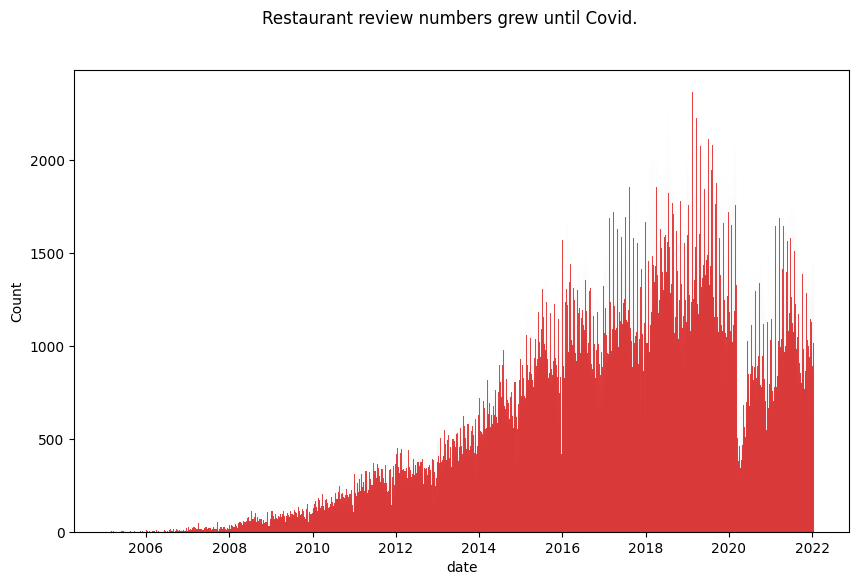

In [66]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=filtered_review_dates, color=YELP_RED)
fig.set_xlabel("date")
plt.suptitle("Restaurant review numbers grew until Covid.")
plt.show()

### Stars

<Axes: xlabel='stars', ylabel='count'>

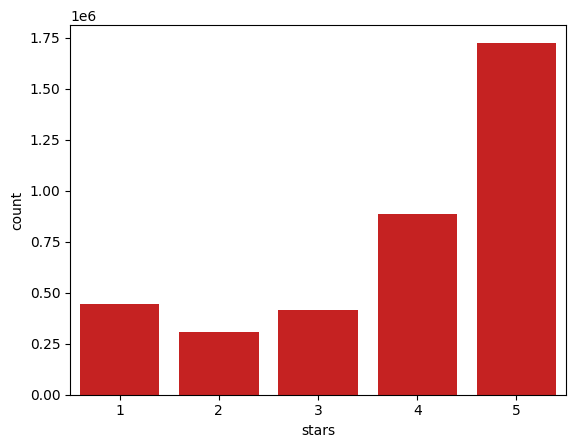

In [67]:
sns.countplot(data=filtered_review, x="stars", color=YELP_RED)

<Axes: xlabel='stars'>

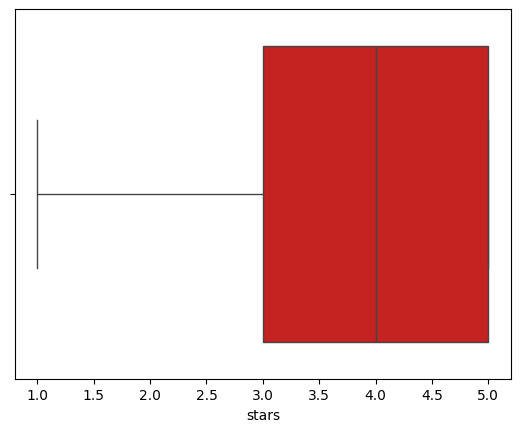

In [68]:
sns.boxplot(data=filtered_review, x="stars", color=YELP_RED)

### Useful, funny, cool

[]

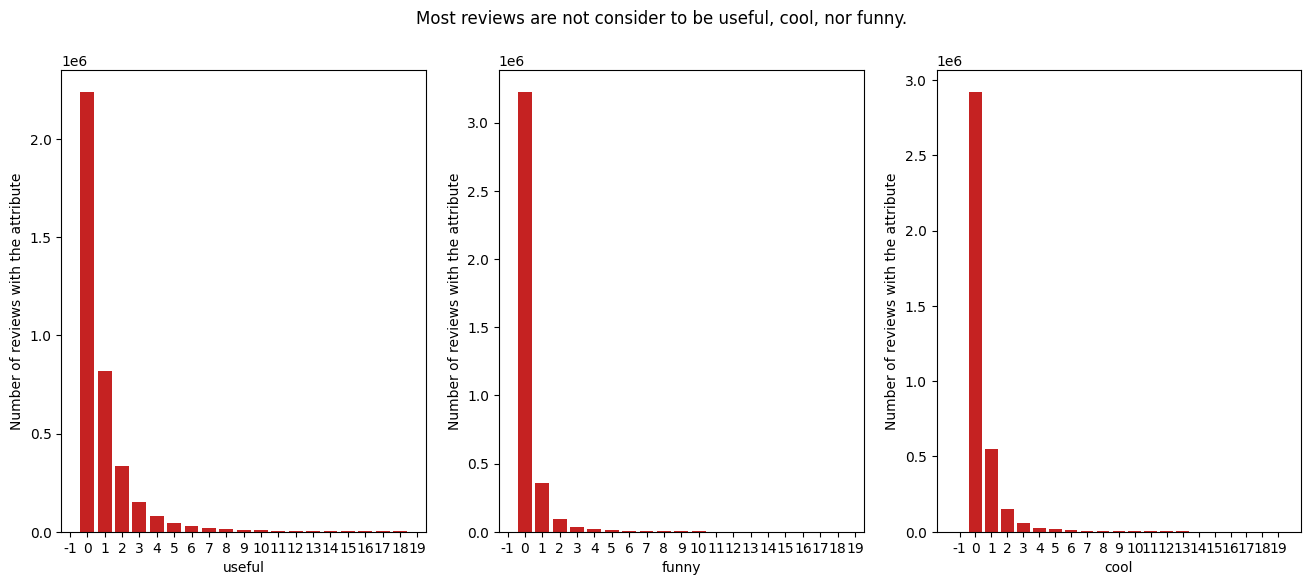

In [69]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=filtered_review[filtered_review["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=filtered_review[filtered_review["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=filtered_review[filtered_review["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of reviews with the attribute")
fig.suptitle("Most reviews are not consider to be useful, cool, nor funny.")
plt.plot()

In [70]:
filtered_review = filtered_review.drop(columns=["useful", "funny", "cool"])
filtered_review

,review_id,user_id,business_id,stars,date,text_length
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,2018-07-07 22:09:11,513
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,2014-02-05 20:30:30,339
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,2015-01-04 00:01:03,243
9,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3,2016-07-25 07:31:06,524
11,l3Wk_mvAog6XANIuGQ9C7Q,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4,2015-08-19 14:31:45,119
...,...,...,...,...,...,...
6990270,7NgXAuTFiJHYbuepOPwU0w,x1QLCwZGFAjxRRw4EHc3-g,1_BVWDzi5cVqWxNe9bOMMQ,5,2016-04-30 01:02:34,890
6990272,wD5ZWao_vjyT2h4xmGam8Q,7L7GL5Pi2cf8mbm2Dpw4zw,e_E-jq9mwm7wk75k7Yi-Xw,5,2022-01-17 22:36:01,336
6990274,YVX1Wsa4LYxjvFwuHBb_gA,RKPkxOYQlM0BjhM-H6_vAw,X4mouE_cMiwbfyCPZ_K-FA,4,2015-01-23 23:52:03,2700
6990278,i-I4ZOhoX70Nw5H0FwrQUA,YwAMC-jvZ1fvEUum6QkEkw,Rr9kKArrMhSLVE9a53q-aA,5,2022-01-19 18:59:27,2317


### Text length

Text(0.5, 1.0, 'Most reviews tend to be around 200 characters long.')

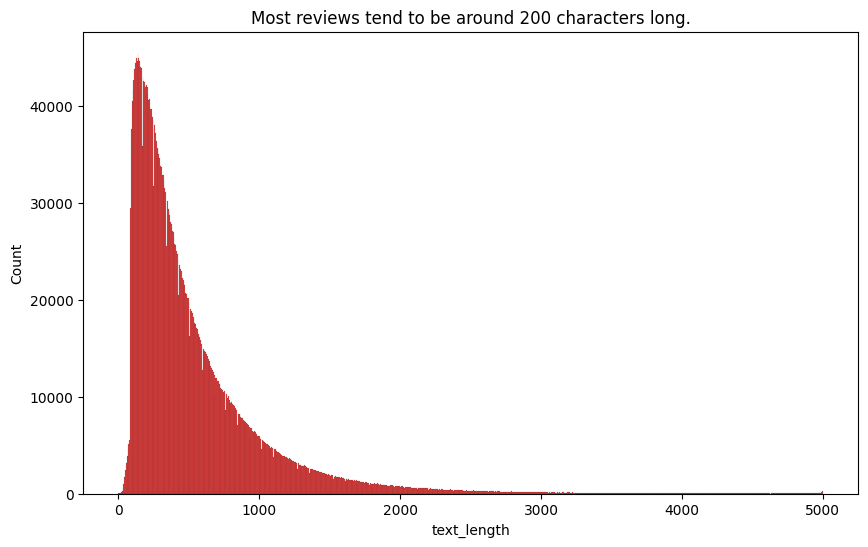

In [71]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=filtered_review, x="text_length", color=YELP_RED)
fig.set_title("Most reviews tend to be around 200 characters long.")

In [72]:
restaurant_user_ids = filtered_review["user_id"].tolist()

In [73]:
review = filtered_review.reset_index(drop=True)
review

,review_id,user_id,business_id,stars,date,text_length
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,2018-07-07 22:09:11,513
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,2014-02-05 20:30:30,339
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,2015-01-04 00:01:03,243
3,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3,2016-07-25 07:31:06,524
4,l3Wk_mvAog6XANIuGQ9C7Q,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4,2015-08-19 14:31:45,119
...,...,...,...,...,...,...
3773765,7NgXAuTFiJHYbuepOPwU0w,x1QLCwZGFAjxRRw4EHc3-g,1_BVWDzi5cVqWxNe9bOMMQ,5,2016-04-30 01:02:34,890
3773766,wD5ZWao_vjyT2h4xmGam8Q,7L7GL5Pi2cf8mbm2Dpw4zw,e_E-jq9mwm7wk75k7Yi-Xw,5,2022-01-17 22:36:01,336
3773767,YVX1Wsa4LYxjvFwuHBb_gA,RKPkxOYQlM0BjhM-H6_vAw,X4mouE_cMiwbfyCPZ_K-FA,4,2015-01-23 23:52:03,2700
3773768,i-I4ZOhoX70Nw5H0FwrQUA,YwAMC-jvZ1fvEUum6QkEkw,Rr9kKArrMhSLVE9a53q-aA,5,2022-01-19 18:59:27,2317


## Tip

In [74]:
tip = pd.read_json(DATASET_PATH / "yelp_academic_dataset_tip.json", lines=True)
tip

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0
...,...,...,...,...,...
908910,eYodOTF8pkqKPzHkcxZs-Q,3lHTewuKFt5IImbXJoFeDQ,Disappointed in one of your managers.,2021-09-11 19:18:57,0
908911,1uxtQAuJ2T5Xwa_wp7kUnA,OaGf0Dp56ARhQwIDT90w_g,Great food and service.,2021-10-30 11:54:36,0
908912,v48Spe6WEpqehsF2xQADpg,hYnMeAO77RGyTtIzUSKYzQ,Love their Cubans!!,2021-11-05 13:18:56,0
908913,ckqKGM2hl7I9Chp5IpAhkw,s2eyoTuJrcP7I_XyjdhUHQ,Great pizza great price,2021-11-20 16:11:44,0


In [75]:
filtered_tip = tip[tip["business_id"].isin(restaurant_ids)]
filtered_tip

,user_id,business_id,text,date,compliment_count
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0
8,VL12EhEdT4OWqGq0nIqkzw,xODBZmX4EmlVvbqtKN7YKg,Tacos,2012-07-27 01:48:24,0
...,...,...,...,...,...
908909,FowxkbAixI3hlREeCgIa_Q,kfNv-JZpuN6TVNSO6hHdkw,Great experience with a phenomenal food with a...,2021-05-09 23:21:10,0
908911,1uxtQAuJ2T5Xwa_wp7kUnA,OaGf0Dp56ARhQwIDT90w_g,Great food and service.,2021-10-30 11:54:36,0
908912,v48Spe6WEpqehsF2xQADpg,hYnMeAO77RGyTtIzUSKYzQ,Love their Cubans!!,2021-11-05 13:18:56,0
908913,ckqKGM2hl7I9Chp5IpAhkw,s2eyoTuJrcP7I_XyjdhUHQ,Great pizza great price,2021-11-20 16:11:44,0


In [76]:
filtered_tip.info()

<class 'pandas.DataFrame'>
Index: 488803 entries, 1 to 908914
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           488803 non-null  str           
 1   business_id       488803 non-null  str           
 2   text              488803 non-null  str           
 3   date              488803 non-null  datetime64[us]
 4   compliment_count  488803 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 22.4 MB


In [77]:
filtered_tip.describe()

,date,compliment_count
count,488803,488803.000000
mean,2015-10-28 18:47:49.371816,0.011440
min,2009-04-16 13:11:49,0.000000
25%,2013-05-24 21:50:03,0.000000
50%,2015-09-20 22:56:06,0.000000
75%,2018-01-30 02:38:11,0.000000
max,2022-01-19 18:42:44,6.000000
std,NaN,0.115565


### Compliment count

[]

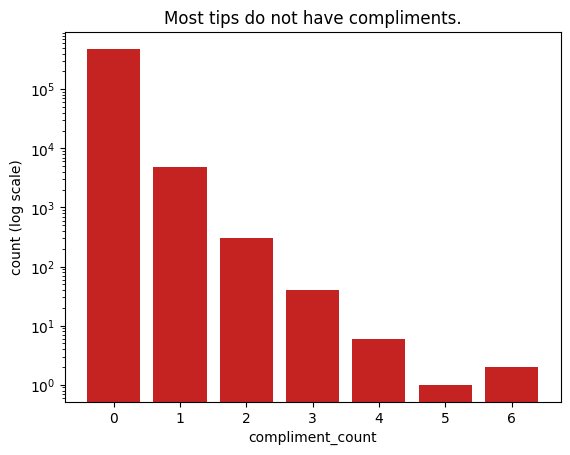

In [78]:
fig = sns.countplot(data=filtered_tip, x="compliment_count", color=YELP_RED)
fig.set_title("Most tips do not have compliments.")
fig.set_ylabel("count (log scale)")
fig.set_yscale("log")
fig.plot()

In [79]:
filtered_tip.drop(columns=["compliment_count"])

,user_id,business_id,text,date
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09
8,VL12EhEdT4OWqGq0nIqkzw,xODBZmX4EmlVvbqtKN7YKg,Tacos,2012-07-27 01:48:24
...,...,...,...,...
908909,FowxkbAixI3hlREeCgIa_Q,kfNv-JZpuN6TVNSO6hHdkw,Great experience with a phenomenal food with a...,2021-05-09 23:21:10
908911,1uxtQAuJ2T5Xwa_wp7kUnA,OaGf0Dp56ARhQwIDT90w_g,Great food and service.,2021-10-30 11:54:36
908912,v48Spe6WEpqehsF2xQADpg,hYnMeAO77RGyTtIzUSKYzQ,Love their Cubans!!,2021-11-05 13:18:56
908913,ckqKGM2hl7I9Chp5IpAhkw,s2eyoTuJrcP7I_XyjdhUHQ,Great pizza great price,2021-11-20 16:11:44


### Date

<Axes: xlabel='date', ylabel='Count'>

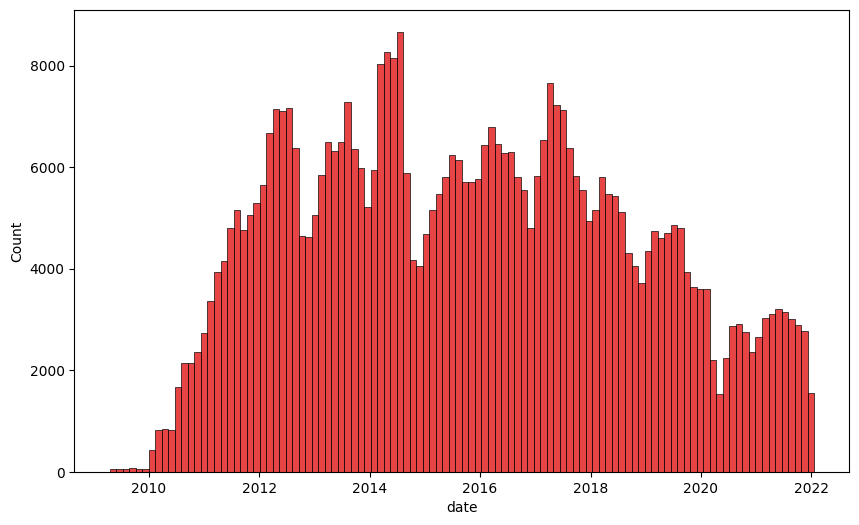

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_tip, x="date", color=YELP_RED)

In [81]:
tip = filtered_tip.reset_index(drop=True)
tip

,user_id,business_id,text,date,compliment_count
0,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
1,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
2,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
3,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0
4,VL12EhEdT4OWqGq0nIqkzw,xODBZmX4EmlVvbqtKN7YKg,Tacos,2012-07-27 01:48:24,0
...,...,...,...,...,...
488798,FowxkbAixI3hlREeCgIa_Q,kfNv-JZpuN6TVNSO6hHdkw,Great experience with a phenomenal food with a...,2021-05-09 23:21:10,0
488799,1uxtQAuJ2T5Xwa_wp7kUnA,OaGf0Dp56ARhQwIDT90w_g,Great food and service.,2021-10-30 11:54:36,0
488800,v48Spe6WEpqehsF2xQADpg,hYnMeAO77RGyTtIzUSKYzQ,Love their Cubans!!,2021-11-05 13:18:56,0
488801,ckqKGM2hl7I9Chp5IpAhkw,s2eyoTuJrcP7I_XyjdhUHQ,Great pizza great price,2021-11-20 16:11:44,0


## User

WARNING: This is a modified version users without the `friends` column.

In [82]:
user = pd.read_csv(CUSTOM_DATASET_PATH / "user_for_vis.csv")
filtered_user = user[user["user_id"].isin(restaurant_user_ids)]
filtered_user

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars,...,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,number_of_friends
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91,...,55,56,18,232,844,467,467,239,180,14995
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74,...,184,157,251,1847,7054,3131,3131,1521,1946,4646
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013",52,3.32,...,10,17,3,66,96,119,119,35,18,381
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011",28,4.27,...,1,6,2,12,16,26,26,10,9,131
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,NaN,1,3.54,...,0,0,0,1,1,0,0,0,0,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1987889,Q5SlTMOwyHq4PIu7Ev-GVg,John,4,2018-01-13 21:55:39,0,0,0,NaN,0,5.00,...,0,0,0,0,0,0,0,0,0,1
1987890,XPNsbtTADPdAsYT-C4xjsA,Jamila,5,2018-02-05 05:47:47,1,0,0,NaN,0,4.60,...,0,0,0,0,0,0,0,0,0,1
1987892,fB3jbHi3m0L2KgGOxBv6uw,Jerrold,23,2015-01-06 00:31:31,7,0,0,NaN,0,4.92,...,0,0,0,0,0,0,0,0,0,1
1987894,1x3KMskYxOuJCjRz70xOqQ,Shomari,4,2017-02-04 15:31:58,1,1,0,NaN,0,2.00,...,0,0,0,0,0,0,0,0,0,1


In [83]:
filtered_user.info()

<class 'pandas.DataFrame'>
Index: 1277283 entries, 0 to 1987896
Data columns (total 22 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1277283 non-null  str    
 1   name                1277262 non-null  str    
 2   review_count        1277283 non-null  int64  
 3   yelping_since       1277283 non-null  str    
 4   useful              1277283 non-null  int64  
 5   funny               1277283 non-null  int64  
 6   cool                1277283 non-null  int64  
 7   elite               80253 non-null    str    
 8   fans                1277283 non-null  int64  
 9   average_stars       1277283 non-null  float64
 10  compliment_hot      1277283 non-null  int64  
 11  compliment_more     1277283 non-null  int64  
 12  compliment_profile  1277283 non-null  int64  
 13  compliment_cute     1277283 non-null  int64  
 14  compliment_list     1277283 non-null  int64  
 15  compliment_note     1277283 non

In [84]:
filtered_user.describe().iloc[1:]

,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,number_of_friends
mean,29.907452,55.894962,22.812317,32.616729,1.951187,3.706948,2.416198,0.384428,0.238811,0.174253,0.085536,1.935280,4.065328,3.81738,3.81738,1.436909,1.693502,58.783084
std,98.405872,779.678547,495.717473,687.405988,22.078622,1.062341,87.862927,15.348637,17.780690,13.863791,12.243899,73.591257,141.388426,114.29812,114.29812,38.278816,116.076065,160.995906
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000
25%,3.000000,1.000000,0.000000,0.000000,0.000000,3.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000
50%,7.000000,4.000000,0.000000,1.000000,0.000000,3.910000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,3.000000
75%,22.000000,17.000000,3.000000,4.000000,0.000000,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,54.000000
max,17473.000000,206296.000000,185823.000000,199878.000000,12497.000000,5.000000,25784.000000,13501.000000,14180.000000,13654.000000,12669.000000,59031.000000,101097.000000,49967.00000,49967.00000,15934.000000,82630.000000,14995.000000


[]

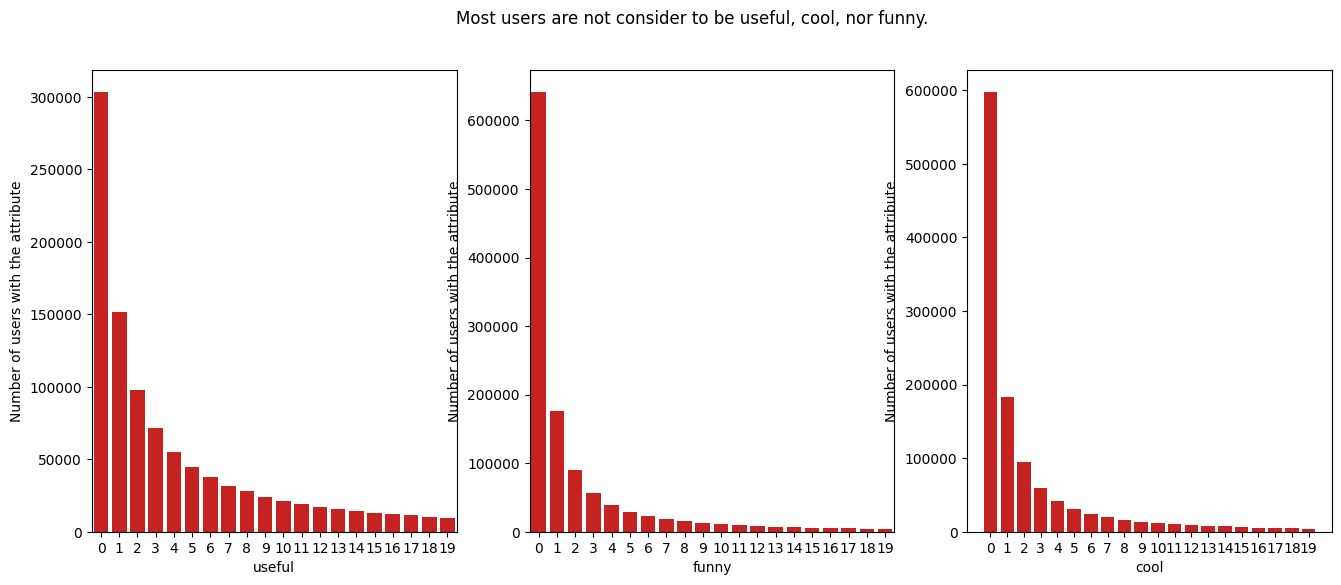

In [85]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=filtered_user[filtered_user["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=filtered_user[filtered_user["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=filtered_user[filtered_user["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users are not consider to be useful, cool, nor funny.")
plt.plot()

In [86]:
filtered_user = filtered_user.drop(columns=["useful", "funny", "cool"])

[]

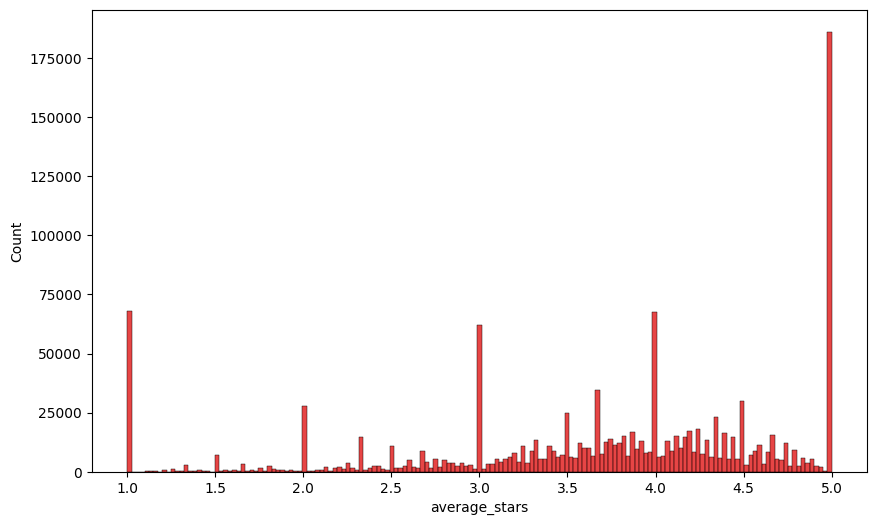

In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_user, x="average_stars", color=YELP_RED)
plt.plot()

In [88]:
filtered_user = filtered_user.drop(columns=["average_stars"])

[]

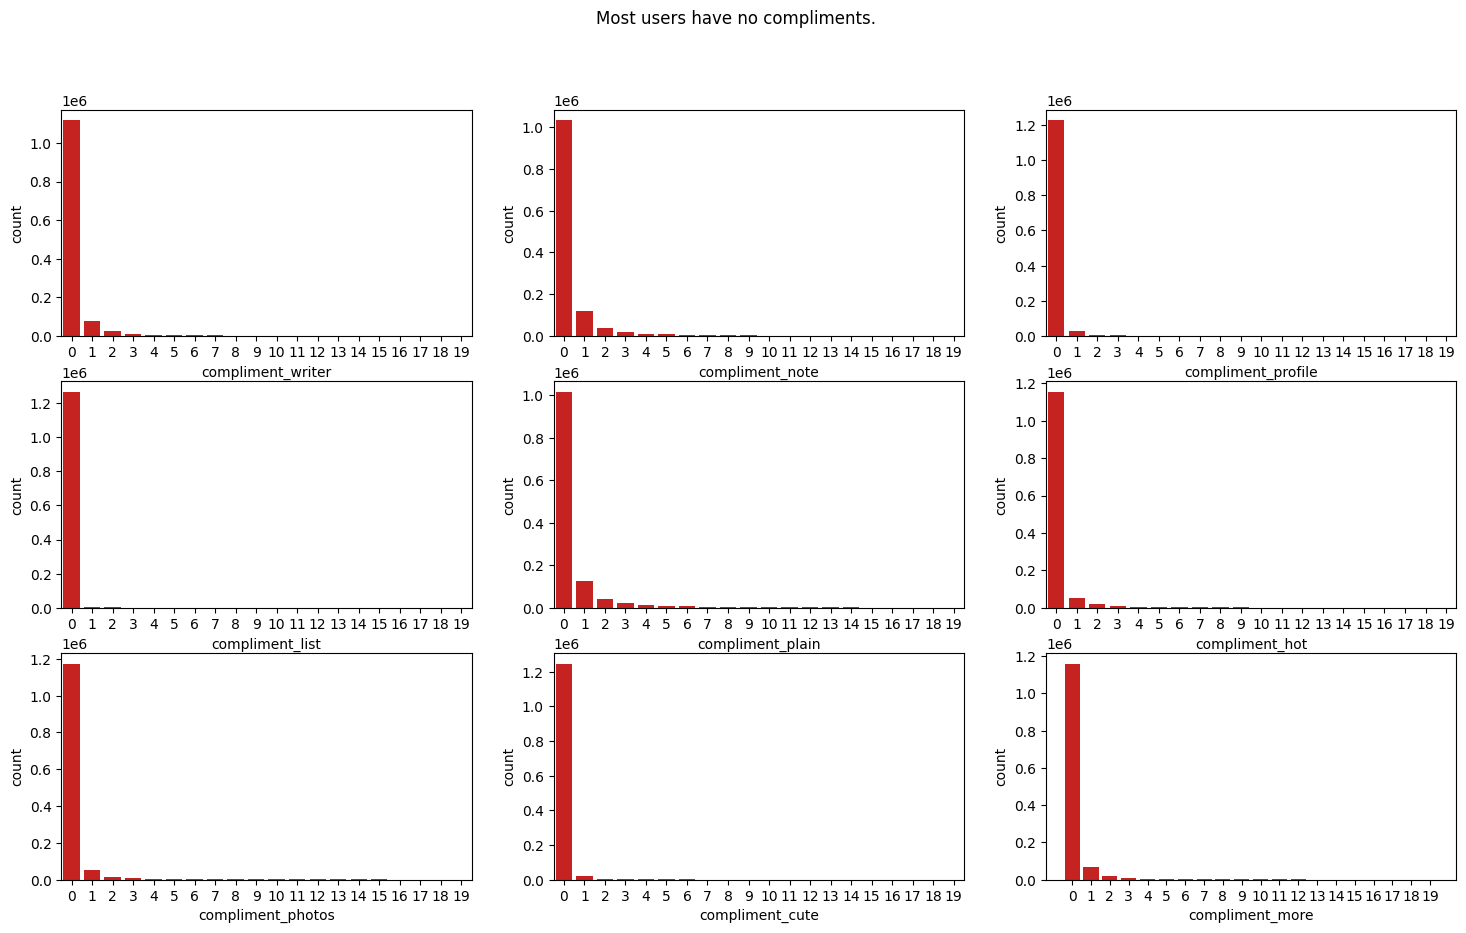

In [89]:
compliment_columns = set(filtered_user.describe().filter(like="compliment_").columns)
compliment_columns = compliment_columns - {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=filtered_user[filtered_user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i//3][i%3])
fig.suptitle("Most users have no compliments.")
plt.plot()

In [90]:
filtered_user = filtered_user.drop(columns=list(compliment_columns))

[]

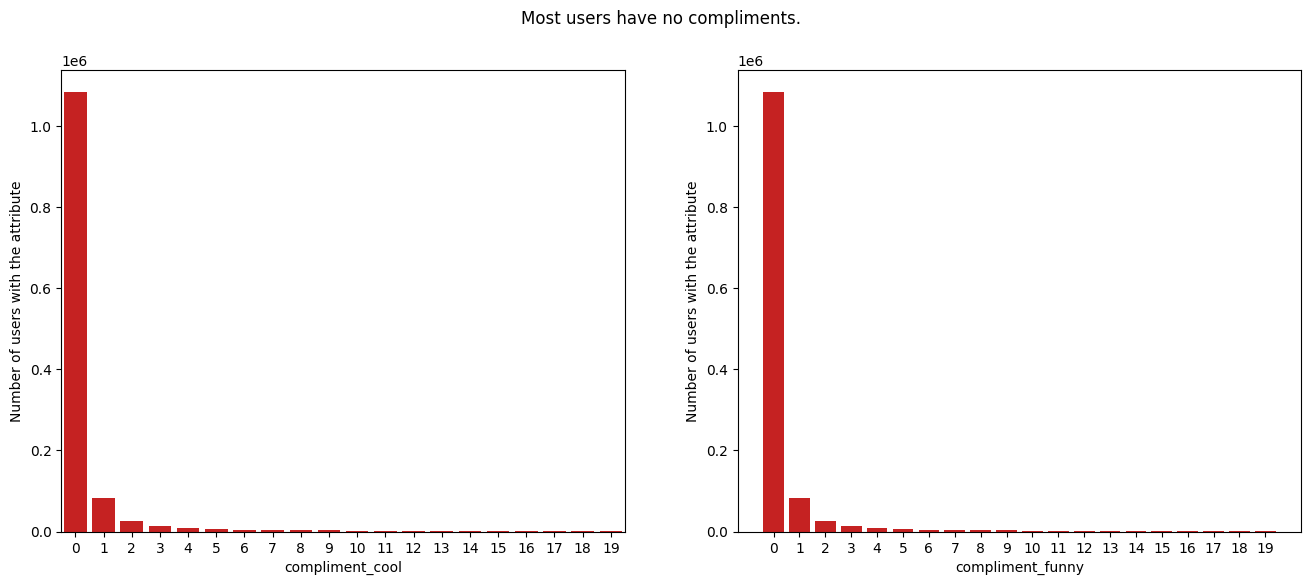

In [91]:
compliment_columns = {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=filtered_user[filtered_user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i])
for ax in axes:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users have no compliments.")
plt.plot()

In [92]:
filtered_user = filtered_user.drop(columns=list(compliment_columns))

[]

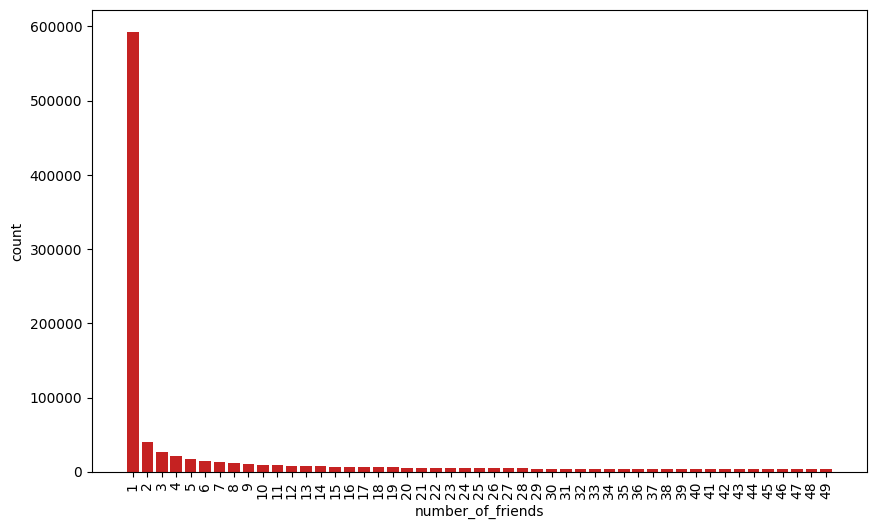

In [93]:
plt.figure(figsize=(10, 6))
sns.countplot(data=filtered_user[filtered_user["number_of_friends"] < 50], x="number_of_friends", color=YELP_RED)
plt.xticks(rotation=90)
fig.suptitle("Most users have just a single friend.")
plt.plot()

In [94]:
filtered_user = filtered_user.drop(columns=["number_of_friends"])

### yelping since

In [95]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
yelping_sinces = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in filtered_user["yelping_since"].tolist()]

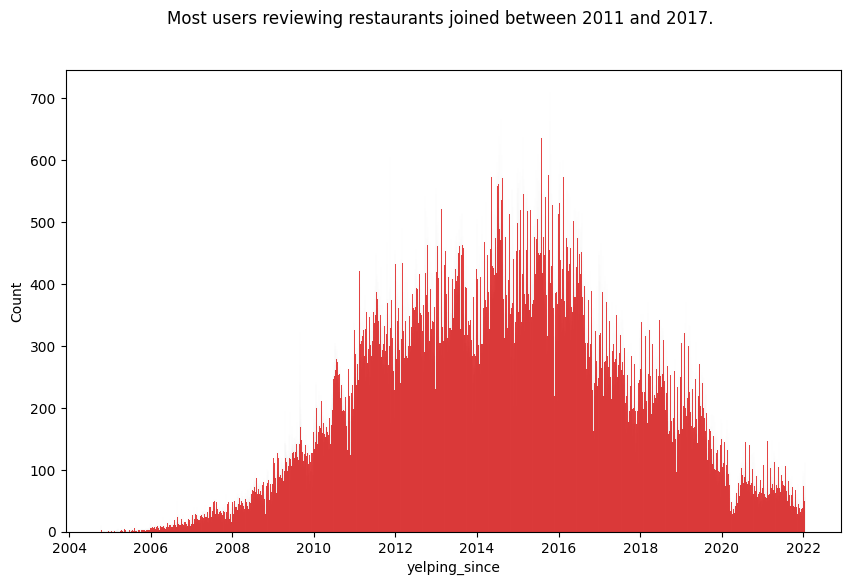

In [96]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=yelping_sinces, color=YELP_RED)
fig.set_xlabel("yelping_since")
plt.suptitle("Most users reviewing restaurants joined between 2011 and 2017.")
plt.show()

### Elite

In [97]:
print("NaNs (%) in elite column:", 100 * float(filtered_user["elite"].isna().sum() / filtered_user["elite"].shape[0]))

NaNs (%) in elite column: 93.71689750822645


In [98]:
filtered_user = filtered_user.drop(columns=["elite"])

### Fans

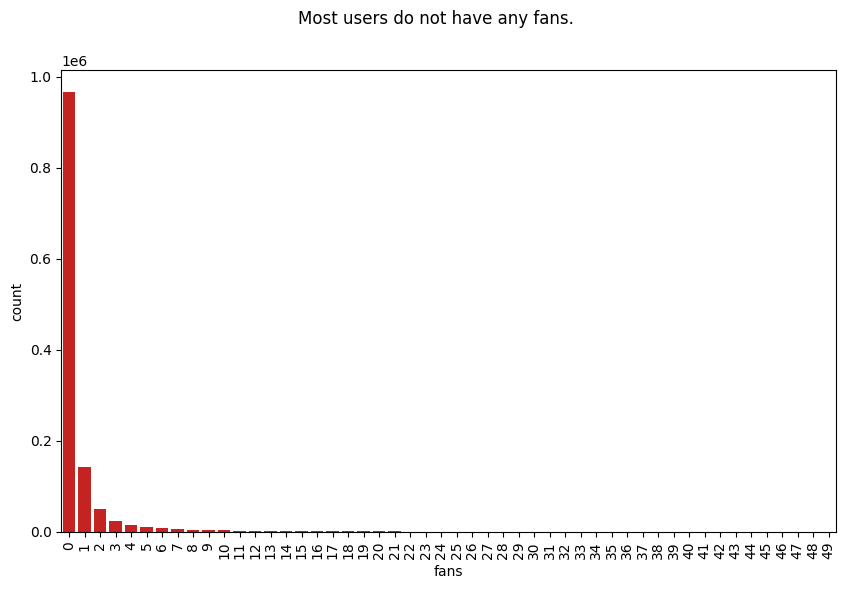

In [99]:
plt.figure(figsize=(10, 6))
fig = sns.countplot(data=filtered_user[filtered_user["fans"] < 50], x="fans", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Most users do not have any fans.")
plt.show()

In [100]:
filtered_user = filtered_user.drop(columns=["fans"])

In [101]:
filtered_user

,user_id,name,review_count,yelping_since
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59
...,...,...,...,...
1987889,Q5SlTMOwyHq4PIu7Ev-GVg,John,4,2018-01-13 21:55:39
1987890,XPNsbtTADPdAsYT-C4xjsA,Jamila,5,2018-02-05 05:47:47
1987892,fB3jbHi3m0L2KgGOxBv6uw,Jerrold,23,2015-01-06 00:31:31
1987894,1x3KMskYxOuJCjRz70xOqQ,Shomari,4,2017-02-04 15:31:58


### Name

We will not be needing the `name` column.

In [102]:
filtered_user = filtered_user.drop(columns=["name"])

### Review count

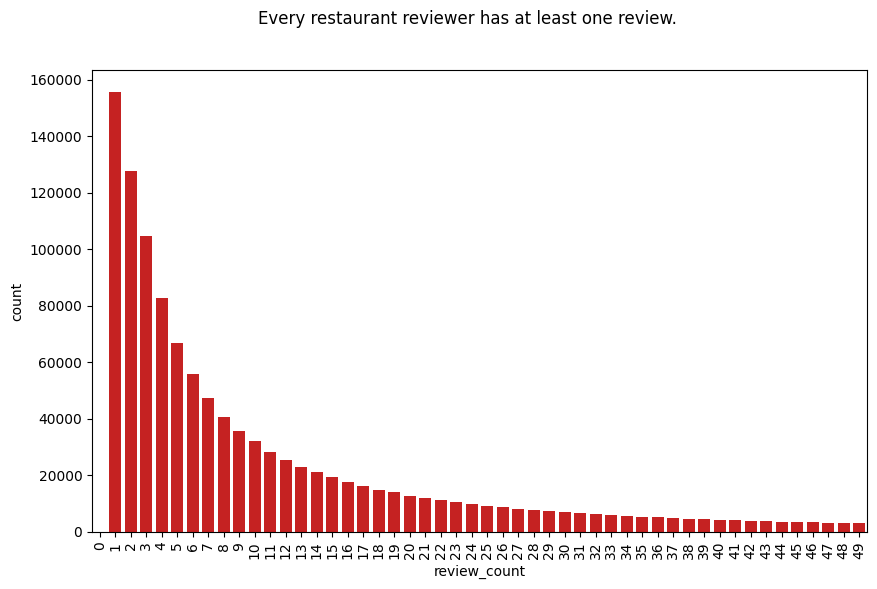

In [103]:
plt.figure(figsize=(10, 6))
fig = sns.countplot(data=filtered_user[filtered_user["review_count"] < 50], x="review_count", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Every restaurant reviewer has at least one review.")
plt.show()

In [104]:
users_sorted_by_stars = review[["user_id", "stars"]].groupby("user_id").count().sort_values(by="stars", ascending=False)

In [105]:
dict_users_vis = {"number_of_stars": [], "number_of_users": []}
for number_of_stars in (users_sorted_by_stars["stars"].unique()):
    users_with_n_stars = users_sorted_by_stars[users_sorted_by_stars["stars"] >= number_of_stars]
    dict_users_vis["number_of_stars"].append(number_of_stars)
    dict_users_vis["number_of_users"].append(users_with_n_stars.shape[0])
with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None
    ):
    display(pd.DataFrame(dict_users_vis).head())

,number_of_stars,number_of_users
0,1156,1
1,1038,2
2,873,3
3,766,4
4,749,5


In [106]:
# filter based on how many reviews we want
users_with_most_stars = users_sorted_by_stars[users_sorted_by_stars["stars"] >= 90]

In [107]:
users_with_most_stars.shape

(1775, 1)

In [108]:
businesses_sorted_by_stars = review[["business_id", "stars"]].groupby("business_id").count().sort_values(by="stars", ascending=False)

In [109]:
dict_businesses_vis = {"number_of_stars": [], "number_of_businesses": []}
for number_of_stars in (businesses_sorted_by_stars["stars"].unique()):
    businesses_with_n_stars = businesses_sorted_by_stars[businesses_sorted_by_stars["stars"] >= number_of_stars]
    dict_businesses_vis["number_of_stars"].append(number_of_stars)
    dict_businesses_vis["number_of_businesses"].append(businesses_with_n_stars.shape[0])
with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None
    ):
    display(pd.DataFrame(dict_businesses_vis).head())

,number_of_stars,number_of_businesses
0,7673,1
1,7516,2
2,6160,3
3,5778,4
4,5264,5


In [110]:
# filter based on how many reviews we want
businesses_with_most_stars = businesses_sorted_by_stars[businesses_sorted_by_stars["stars"] >= 800]

In [111]:
businesses_with_most_stars.shape

(465, 1)

In [112]:
filtered_review = review[(review["user_id"].isin(users_with_most_stars.index)) & (review["business_id"].isin(businesses_with_most_stars.index))]
filtered_review

,review_id,user_id,business_id,stars,date,text_length
176,tfucaiy6lG5UbvbmTD4STg,wABHp4fGUC-0acRKhmQO2A,MMRRS6YhVRx_iN5-JhMRYg,5,2016-03-07 00:22:02,249
435,fMGOJq3i_DUUukBg7QU9SA,o6UJMpHcpLJEvmKLrxLS3w,0qu0fNTOsSmuREYVIMPuIQ,4,2016-10-14 03:44:53,422
437,pIyQ9YmxoQ-UrIs-ANTi8Q,7ktyPHE-NGnWxarOqjIQiQ,EtKSTHV5Qx_Q7Aur9o4kQQ,4,2010-08-22 01:09:23,2016
624,eUQcUHjP38IKn39oXA8hzA,sgK8_cpe6FTk2HD0P27K0g,JUlsvVAvZvGHWFfkKm0nlg,4,2012-08-15 13:52:03,157
696,1aNrSU9CHuFnBuNFTD2cBQ,kulP4rgLtL6FGAOtOgh9pw,I0I2mkCOPTYVSLpc8A8VVw,4,2016-02-23 22:17:29,1168
...,...,...,...,...,...,...
3773015,ZHUej6nzle9Gl6oEQVqIVQ,6toEhpmJxknHFKBw5u3xWQ,VAeEXLbEcI9Emt9KGYq9aA,4,2014-12-07 01:33:32,1044
3773333,Xb56_YVY4ocJ7zYgB155Jw,pLE9PzQ-3BNFbGjrMSxo2Q,QHWYlmVbLC3K6eglWoHVvA,2,2015-05-04 00:06:56,1149
3773440,--q-8CWlgnehsZMGRZToog,YrlNGnrofZHseVYxrLrvJA,-VlBFlHwX-Pt6Xyzs9roGw,4,2016-01-16 15:54:09,1392
3773675,nYO-ksJhFKd_O5G2sB5kcg,1pR5fCGVpPydBbu94KGi_Q,1b5mnK8bMnnju_cvU65GqQ,5,2018-08-18 15:28:57,252


In [113]:
pt = filtered_review.pivot_table(index="user_id", columns="business_id", values="stars")
(pt.isnull().sum() / pt.shape[0]).mean()

np.float64(0.9678855544315812)

In [114]:
(pt.T.isnull().sum() / pt.T.shape[0]).mean()

np.float64(0.9678855544315812)

In [115]:
pt = pt.dropna(axis=0, how="all").dropna(axis=1, how="all")
print((pt.isnull().sum() / pt.shape[0]).mean())
print((pt.T.isnull().sum() / pt.T.shape[0]).mean())

0.9678855544315812
0.9678855544315812


In [116]:
total_nan_count = pt.isnull().sum().sum()
print("Total NaN count:", total_nan_count)
print("Total ratio:", total_nan_count / math.prod(pt.shape))

Total NaN count: 775015
Total ratio: 0.9678855544315812


# Collaborative filtering

In [117]:
pt = pt.fillna(0)

In [118]:
pt

business_id,-0TffRSXXIlBYVbb5AwfTg,-1B9pP_CrRBJYPICE5WbRA,-EHrU_DwtX2Jv4NbAMppTA,-FM4CxOg4XXmX_Ebky_SiQ,-Tskf8WK17rb3ZfeFuRSWA,-VlBFlHwX-Pt6Xyzs9roGw,-cEFKAznWmI0cledNOIQ7w,-ejuzGbu3ZHUndhLTQafJg,-lX4ufgPLYubI8rVxNM31w,-mIlmp5l4hKlp1tvHRdvTg,...,yeHLiKNp0hyR-ig4M6us-w,yoQBK3OUDqWEFoUDE5lM4w,ytynqOUb3hjKeJfRj5Tshw,yz0KWVamNhqiZGz7XTClzg,z4pCmH_yphNtse3ySNCzFw,zJmp_J8SUNosLxk6borpFg,zT2OzXDWKK1abapHs2RUrQ,zZ01WQlcpI1_n806WKV3bA,z_7TZeTXsDH6MmkPHQN8nQ,zwrgCMuZyFX46mL3piDyjg
user_id,,,,,,,,,,,,,,,,,,,,,
-3s52C4zL_DHRK0ULG6qtg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-7XrSrJfHndHc_taEXurTw,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0
-7qUbOVWJp2NT3f_TNuIBA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
-B-QEUESGWHPE_889WJaeg,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-CzwjrantVGMmZB8Qj_7-Q,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zsXoPyTcU8ThZGbtAB-Vug,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zu-e06_BM_TdkAZEKMrIww,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zv7tpu7xeaNyAeFG03d2CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
scaler = StandardScaler(with_mean=True, with_std=True)
pivot_table_normalized = scaler.fit_transform(pt)

In [120]:
similarity_score = cosine_similarity(pivot_table_normalized)

In [121]:
user_to_recommend = "wABHp4fGUC-0acRKhmQO2A"
index = np.where(pt.index==user_to_recommend)[0][0]
k = 10 
similar_restaurants = sorted(list(enumerate(similarity_score[index])),key=lambda x:x[1], reverse=True)[1:k+1]
for index, similarity in similar_restaurants:
    print(review.iloc[index]["business_id"])
    print(similarity)
    print()

bJAY2baMKSTlWRc-QZGopQ
0.5272365662551705

Zi-F-YvyVOK0k5QD7lrLOg
0.5068398291789793

L-YdO_NODKXXT3bkS0nUpg
0.49504576499541697

vC2qm1y3Au5czBtbhc-DNw
0.48350227988625605

LRGbuufLJqxsDYsY7_Gx6A
0.4678491469658772

g04aAvgol7IW8buqSbT4xA
0.45954241555886133

0JPi9cyV9i3_kDPj049_qQ
0.45759110611278986

sLgnx_WFCjEoPsS6NwU70Q
0.4574696686253559

9V0LMtO1riRw9-pUuG4NFg
0.44587218961340797

oqP1oQEycpp4J6u5YebRoQ
0.4260185386645087



- 1.zad = user matica (collaborative / hybrid = prve dva / tri notebooky z week_02) / sekvencne (asi by sme predikovali checkin? TOTO URCITE NIE, chyba user_id)
- 2.zad = deep learning

pri druhom zadani este teoreticky mozeme zmenit dataset, ak by nevyhovoval

podla priemerneho poctu recenzii v mestach (alebo poctu hviezdiciek)
pomocou LLM vytiahnut z recenzii booleany o zakaznikoch (preferuje_nizke_ceny, ma_rad_taliansku_kuchynu)
checkiny mozeme ignorovat
ak si zvolime businessy, co maju malo recenzii (vacsina ma od 5 do 15), tak nemozeme robit time-weighted recommendation ako v ElasticSearch
datumy recenzii mozeme vyhodit ak nebudeme robit time weight-based boost (asi nebudeme malo recenzii)



CHECKIN preč!

mozeme analyzovat aj tipy (zatiaľ; ak z nich nič nebude, tak ich vyhodíme)

opening / closing (mozno cez rozdiel closing - opening este zistime)
este poriesit atributy, je tam vela chybajucich hodnot (1 = true, 0 = false, 0.5 = nan??)
geoudaje okrem mesta a štátu definitivne vyhodit
postal code a meno businessu tiez nemusime riesit

is_open = 0 vyhodit
elite z userov vyhodit
useful, funny a cool z userov vyhodit, vacsina ma aj tak 0
average_stars moze ist prec
complimenty prec, z businesses tiez vyhodit useful, funny, cool
number_of_friends moze ist prec (friends ako taki asi tiez)
este by som mozno do dokumentacie NEZABUDOL napisat, ze sme neriesili photos.json